DATASET OVERVIEW
Shape: (2240, 29)

Target distribution (Response):
Response
0    1906
1     334
Name: count, dtype: int64

Missing values per column:
Income    24
dtype: int64

Feature matrix shape: (500, 18)
Target shape: (500,)
Any NaN in X? False
Features used: ['Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth']

Train shape: (350, 18) | Test shape: (150, 18)

A4-A6: Custom kNN with k = 3
Custom kNN (k=3) Accuracy: 0.8400
First 20 predictions: [0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0]
First 20 actual     : [0 1 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1]

(A7) fit() / predict() / score() are implemented as methods of CustomKNN.

A8: Custom vs sklearn kNN for a range of k


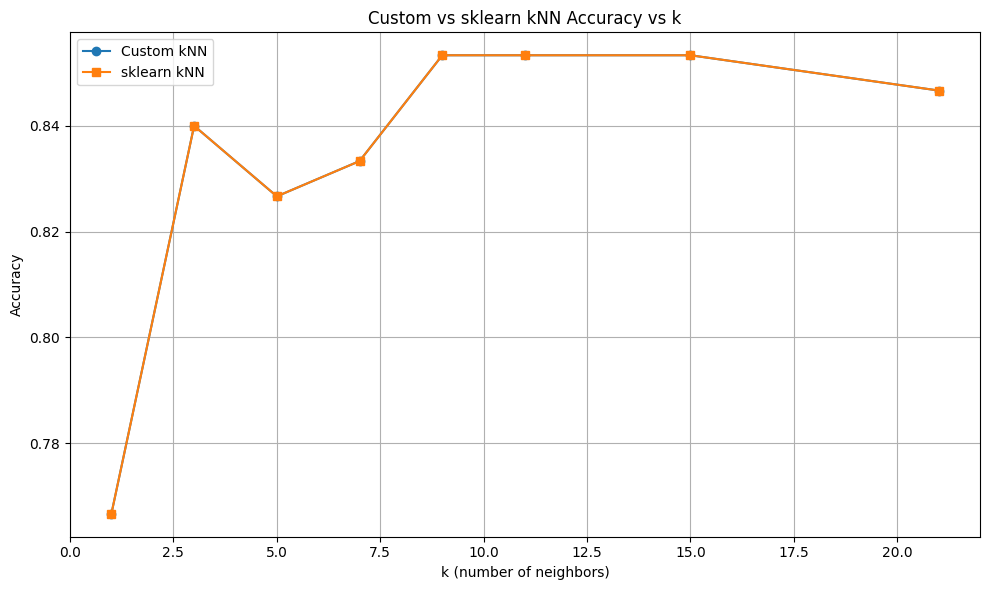


   k |   Custom |  sklearn
----------------------------
   1 |   0.7667 |   0.7667
   3 |   0.8400 |   0.8400
   5 |   0.8267 |   0.8267
   7 |   0.8333 |   0.8333
   9 |   0.8533 |   0.8533
  11 |   0.8533 |   0.8533
  15 |   0.8533 |   0.8533
  21 |   0.8467 |   0.8467

A9: Weighted kNN comparison


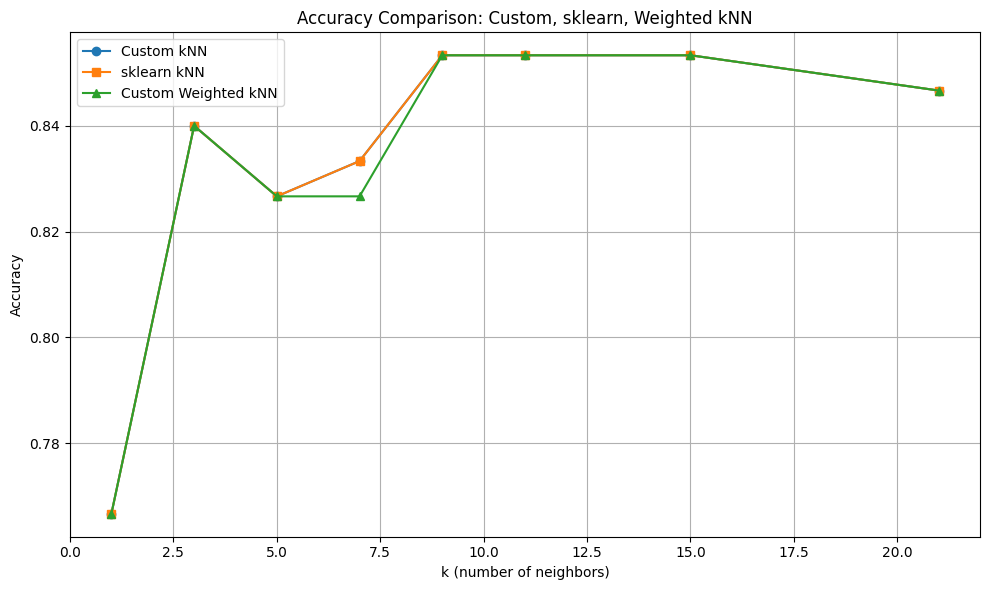


   k |   Custom |  sklearn | Weighted
----------------------------------------
   1 |   0.7667 |   0.7667 |   0.7667
   3 |   0.8400 |   0.8400 |   0.8400
   5 |   0.8267 |   0.8267 |   0.8267
   7 |   0.8333 |   0.8333 |   0.8267
   9 |   0.8533 |   0.8533 |   0.8533
  11 |   0.8533 |   0.8533 |   0.8533
  15 |   0.8533 |   0.8533 |   0.8533
  21 |   0.8467 |   0.8467 |   0.8467

Effect of Sorting Algorithm (k=5, euclidean)
  sort=   bubble: accuracy = 0.8267
  sort=insertion: accuracy = 0.8267
  sort=    merge: accuracy = 0.8267

Effect of Distance Metric (k=5, merge sort)
  metric= euclidean: accuracy = 0.8267
  metric= manhattan: accuracy = 0.8533
  metric= minkowski: accuracy = 0.8600

Train vs Test Accuracy (Custom kNN, euclidean)
   k |    Train |     Test |      Gap
------------------------------------
   1 |   1.0000 |   0.7667 |   0.2333
   3 |   0.8943 |   0.8400 |   0.0543
   5 |   0.8800 |   0.8267 |   0.0533
   7 |   0.8686 |   0.8333 |   0.0352
   9 |   0.8686 |   0.853

In [3]:
# ============================================================
# Lab 5 - k-Nearest Neighbors (from scratch)  +  sklearn compare
# ------------------------------------------------------------
# Coding rules followed:
#   R1: Modular - each functionality is a function
#   R2: NO print() inside any helper function; prints only in main()
#   R3: Proper variable naming
#   R4: Inline documentation / docstrings
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
import warnings
warnings.filterwarnings('ignore')


# ============================================================
# MODULE 1: DATA LOADING
# ============================================================
def load_dataset(file_path, sheet_name='marketing_campaign'):
    """Load the raw dataset from an Excel file. Returns a DataFrame."""
    df = pd.read_excel(file_path, sheet_name=sheet_name)
    return df


# ============================================================
# MODULE 2: ENCODING
# ============================================================
def encode_categorical(df, columns):
    """Label-encode categorical columns. Returns (encoded_df, encoders_dict)."""
    df_encoded = df.copy()
    encoders = {}
    for col in columns:
        le = LabelEncoder()
        df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
        encoders[col] = le
    return df_encoded, encoders


# ============================================================
# MODULE 3: DATA IMPUTATION
# ============================================================
def impute_missing(df, strategy='mean', columns=None):
    """Impute missing values using mean / median / mode on the given columns."""
    if strategy not in ('mean', 'median', 'mode'):
        raise ValueError("strategy must be 'mean', 'median', or 'mode'")

    df_imputed = df.copy()
    target_cols = columns if columns is not None else df_imputed.columns

    for col in target_cols:
        if df_imputed[col].isnull().any():
            if strategy == 'mean':
                fill_val = df_imputed[col].mean()
            elif strategy == 'median':
                fill_val = df_imputed[col].median()
            else:  # mode
                mode_series = df_imputed[col].mode()
                fill_val = mode_series.iloc[0] if not mode_series.empty else 0
            df_imputed[col] = df_imputed[col].fillna(fill_val)
    return df_imputed


# ============================================================
# MODULE 4: DISTANCE CALCULATION
# ============================================================
def calculate_distance(point1, point2, metric='euclidean'):
    """Return the distance between two vectors for the chosen metric."""
    p1 = np.asarray(point1, dtype=float)
    p2 = np.asarray(point2, dtype=float)

    if metric == 'euclidean':
        return float(np.sqrt(np.sum((p1 - p2) ** 2)))
    elif metric == 'manhattan':
        return float(np.sum(np.abs(p1 - p2)))
    elif metric == 'minkowski':
        return float(np.sum(np.abs(p1 - p2) ** 3) ** (1.0 / 3.0))
    else:
        raise ValueError(f"Unsupported metric: {metric}")


# ============================================================
# MODULE 5a: SORTING ALGORITHMS (configurable)
# ============================================================
def bubble_sort(arr):
    """Bubble sort on (distance, index, label) tuples by distance (stable on ties)."""
    a = list(arr)
    n = len(a)
    for i in range(n):
        for j in range(0, n - i - 1):
            if a[j][0] > a[j + 1][0]:
                a[j], a[j + 1] = a[j + 1], a[j]
    return a


def insertion_sort(arr):
    """Insertion sort by distance (stable)."""
    a = list(arr)
    for i in range(1, len(a)):
        key = a[i]
        j = i - 1
        while j >= 0 and a[j][0] > key[0]:
            a[j + 1] = a[j]
            j -= 1
        a[j + 1] = key
    return a


def merge_sort(arr):
    """Merge sort by distance (stable)."""
    if len(arr) <= 1:
        return arr
    mid = len(arr) // 2
    left = merge_sort(arr[:mid])
    right = merge_sort(arr[mid:])
    return _merge(left, right)


def _merge(left, right):
    """Helper for merge_sort. Uses <= for stable merge."""
    result = []
    i = j = 0
    while i < len(left) and j < len(right):
        if left[i][0] <= right[j][0]:
            result.append(left[i]); i += 1
        else:
            result.append(right[j]); j += 1
    result.extend(left[i:])
    result.extend(right[j:])
    return result


def sort_distances(distances, algorithm='merge'):
    """Dispatcher that selects the sorting algorithm."""
    if algorithm == 'bubble':
        return bubble_sort(distances)
    elif algorithm == 'insertion':
        return insertion_sort(distances)
    elif algorithm == 'merge':
        return merge_sort(distances)
    else:
        raise ValueError(f"Unknown sorting algorithm: {algorithm}")


# ============================================================
# MODULE 6: IDENTIFY NEIGHBORS (with deterministic tie-breaking)
# ============================================================
def identify_neighbors(distances, k):
    """
    Pick the top-k neighbors.
    Tie-breaking rule: if two candidates have equal distance,
    the one with the smaller training index wins (deterministic).
    """
    sorted_d = sorted(distances, key=lambda x: (x[0], x[1]))
    return sorted_d[:k]


# ============================================================
# MODULE 7: CLASS EVALUATION AND ASSIGNMENT
# ============================================================
def majority_vote(neighbors, weighted=False):
    """
    Majority voting with optional 1/distance weighting.
    Tie-breaking rule: pick the lexicographically smaller label on ties.
    """
    if weighted:
        votes = {}
        for dist, _, label in neighbors:
            w = 1.0 / (dist + 1e-9)
            votes[label] = votes.get(label, 0.0) + w
    else:
        votes = Counter([label for _, _, label in neighbors])

    max_votes = max(votes.values())
    winners = sorted([lbl for lbl, v in votes.items() if v == max_votes])
    return winners[0]


# ============================================================
# CUSTOM kNN CLASS  (fit / predict / score)
# ============================================================
class CustomKNN:
    """Modular k-Nearest Neighbors classifier implemented from scratch."""

    def __init__(self, k=3, metric='euclidean', sort_algo='merge', weighted=False):
        self.k = k
        self.metric = metric
        self.sort_algo = sort_algo
        self.weighted = weighted
        self.X_train = None
        self.y_train = None

    def fit(self, X, y):
        """Store training data. (No print statements.)"""
        self.X_train = np.array(X, dtype=float)
        self.y_train = np.array(y)
        return self

    def _predict_one(self, x):
        """Predict the label of a single test vector."""
        distances = []
        for idx, x_train in enumerate(self.X_train):
            d = calculate_distance(x, x_train, self.metric)
            distances.append((d, idx, self.y_train[idx]))
        sorted_distances = sort_distances(distances, self.sort_algo)
        neighbors = identify_neighbors(sorted_distances, self.k)
        return majority_vote(neighbors, weighted=self.weighted)

    def predict(self, X):
        """Predict labels for a batch of test vectors."""
        X = np.array(X, dtype=float)
        return np.array([self._predict_one(x) for x in X])

    def score(self, X, y):
        """Return mean accuracy on (X, y)."""
        y = np.array(y)
        preds = self.predict(X)
        return float(np.mean(preds == y))


# ============================================================
# MODULE 8: PREPROCESSING PIPELINE
# ============================================================
def preprocess(df, target_col='Response', drop_cols=None, n_samples=None,
               num_impute='mean', cat_impute='mode', random_state=42):
    """
    Full preprocessing pipeline:
      1. Optionally sub-sample
      2. Drop irrelevant columns
      3. Separate numeric / categorical
      4. Impute missing
      5. Encode categoricals
      6. Scale numeric features
    Returns: X (ndarray), y (ndarray), feature_names (list)
    """
    df_work = df.copy()

    if n_samples is not None and n_samples < len(df_work):
        df_work = df_work.sample(n=n_samples, random_state=random_state).reset_index(drop=True)

    if drop_cols:
        df_work = df_work.drop(columns=[c for c in drop_cols if c in df_work.columns])

    y = df_work[target_col].values
    X_df = df_work.drop(columns=[target_col]).copy()

    num_cols = X_df.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = X_df.select_dtypes(include=['object']).columns.tolist()

    X_df = impute_missing(X_df, strategy=num_impute, columns=num_cols)
    X_df = impute_missing(X_df, strategy=cat_impute, columns=cat_cols)

    X_enc, _ = encode_categorical(X_df, cat_cols)
    X_enc = X_enc.apply(pd.to_numeric, errors='coerce').fillna(0)

    scaler = StandardScaler()
    X = scaler.fit_transform(X_enc.values)

    return X, y, list(X_enc.columns)


# ============================================================
# MAIN PROGRAM  (all prints here)
# ============================================================
def main():
    # ---------------- Configurable path (UPDATED) ----------------
    file_path = r"D:\C drive files\Downloads\Lab Session Data (1) (1).xlsx"
    sheet_name = 'marketing_campaign'

    if not os.path.exists(file_path):
        raise FileNotFoundError(f"Excel file not found at: {file_path}")

    # ---------------- Load ----------------
    print("=" * 60)
    print("DATASET OVERVIEW")
    print("=" * 60)

    df = load_dataset(file_path, sheet_name=sheet_name)
    print("Shape:", df.shape)
    print("\nTarget distribution (Response):")
    print(df['Response'].value_counts())
    print("\nMissing values per column:")
    print(df.isnull().sum()[df.isnull().sum() > 0])

    # ---------------- Preprocess ----------------
    # Dropping AcceptedCmp* to avoid data leakage into the Response target.
    drop_cols = ['ID', 'Dt_Customer', 'Z_CostContact', 'Z_Revenue',
                 'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3',
                 'AcceptedCmp4', 'AcceptedCmp5', 'Complain']

    X, y, feature_names = preprocess(
        df,
        target_col='Response',
        drop_cols=drop_cols,
        n_samples=500,
        num_impute='mean',
        cat_impute='mode',
        random_state=42,
    )

    print("\nFeature matrix shape:", X.shape)
    print("Target shape:", y.shape)
    print("Any NaN in X?", np.isnan(X).any())
    print("Features used:", feature_names)

    # ---------------- A3: Train/Test Split ----------------
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )
    print("\nTrain shape:", X_train.shape, "| Test shape:", X_test.shape)

    # ---------------- A4, A5, A6: Custom kNN (k=3) ----------------
    print("\n" + "=" * 60)
    print("A4-A6: Custom kNN with k = 3")
    print("=" * 60)

    custom_knn = CustomKNN(k=3, metric='euclidean', sort_algo='merge', weighted=False)
    custom_knn.fit(X_train, y_train)

    custom_acc = custom_knn.score(X_test, y_test)
    print(f"Custom kNN (k=3) Accuracy: {custom_acc:.4f}")

    custom_preds = custom_knn.predict(X_test)
    print("First 20 predictions:", custom_preds[:20])
    print("First 20 actual     :", y_test[:20])

    # ---------------- A7 ----------------
    print("\n(A7) fit() / predict() / score() are implemented as methods of CustomKNN.")

    # ---------------- A8: Compare with sklearn ----------------
    print("\n" + "=" * 60)
    print("A8: Custom vs sklearn kNN for a range of k")
    print("=" * 60)

    k_values = [1, 3, 5, 7, 9, 11, 15, 21]
    custom_accs, sklearn_accs = [], []

    for k in k_values:
        ck = CustomKNN(k=k, metric='euclidean', sort_algo='merge')
        ck.fit(X_train, y_train)
        custom_accs.append(ck.score(X_test, y_test))

        sk = KNeighborsClassifier(n_neighbors=k)
        sk.fit(X_train, y_train)
        sklearn_accs.append(sk.score(X_test, y_test))

    plt.figure(figsize=(10, 6))
    plt.plot(k_values, custom_accs, marker='o', label='Custom kNN')
    plt.plot(k_values, sklearn_accs, marker='s', label='sklearn kNN')
    plt.xlabel('k (number of neighbors)')
    plt.ylabel('Accuracy')
    plt.title('Custom vs sklearn kNN Accuracy vs k')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig('knn_comparison.png', dpi=100)
    plt.show()

    print(f"\n{'k':>4} | {'Custom':>8} | {'sklearn':>8}")
    print("-" * 28)
    for k, c, s in zip(k_values, custom_accs, sklearn_accs):
        print(f"{k:>4} | {c:>8.4f} | {s:>8.4f}")

    # ---------------- A9: Weighted kNN ----------------
    print("\n" + "=" * 60)
    print("A9: Weighted kNN comparison")
    print("=" * 60)

    weighted_accs = []
    for k in k_values:
        wk = CustomKNN(k=k, metric='euclidean', sort_algo='merge', weighted=True)
        wk.fit(X_train, y_train)
        weighted_accs.append(wk.score(X_test, y_test))

    plt.figure(figsize=(10, 6))
    plt.plot(k_values, custom_accs, marker='o', label='Custom kNN')
    plt.plot(k_values, sklearn_accs, marker='s', label='sklearn kNN')
    plt.plot(k_values, weighted_accs, marker='^', label='Custom Weighted kNN')
    plt.xlabel('k (number of neighbors)')
    plt.ylabel('Accuracy')
    plt.title('Accuracy Comparison: Custom, sklearn, Weighted kNN')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig('knn_weighted_comparison.png', dpi=100)
    plt.show()

    print(f"\n{'k':>4} | {'Custom':>8} | {'sklearn':>8} | {'Weighted':>8}")
    print("-" * 40)
    for k, c, s, w in zip(k_values, custom_accs, sklearn_accs, weighted_accs):
        print(f"{k:>4} | {c:>8.4f} | {s:>8.4f} | {w:>8.4f}")

    # ---------------- Effect of Sorting Algorithm ----------------
    print("\n" + "=" * 60)
    print("Effect of Sorting Algorithm (k=5, euclidean)")
    print("=" * 60)
    for algo in ['bubble', 'insertion', 'merge']:
        ck = CustomKNN(k=5, metric='euclidean', sort_algo=algo)
        ck.fit(X_train, y_train)
        print(f"  sort={algo:>9}: accuracy = {ck.score(X_test, y_test):.4f}")

    # ---------------- Effect of Distance Metric ----------------
    print("\n" + "=" * 60)
    print("Effect of Distance Metric (k=5, merge sort)")
    print("=" * 60)
    for metric in ['euclidean', 'manhattan', 'minkowski']:
        ck = CustomKNN(k=5, metric=metric, sort_algo='merge')
        ck.fit(X_train, y_train)
        print(f"  metric={metric:>10}: accuracy = {ck.score(X_test, y_test):.4f}")

    # ---------------- Train vs Test (overfit/underfit) ----------------
    print("\n" + "=" * 60)
    print("Train vs Test Accuracy (Custom kNN, euclidean)")
    print("=" * 60)
    print(f"{'k':>4} | {'Train':>8} | {'Test':>8} | {'Gap':>8}")
    print("-" * 36)

    gaps = []
    for k in k_values:
        ck = CustomKNN(k=k, metric='euclidean', sort_algo='merge')
        ck.fit(X_train, y_train)
        tr = ck.score(X_train, y_train)
        te = ck.score(X_test, y_test)
        gap = tr - te
        gaps.append(gap)
        print(f"{k:>4} | {tr:>8.4f} | {te:>8.4f} | {gap:>8.4f}")

    best_k = k_values[int(np.argmax(custom_accs))]
    print(f"Best custom kNN accuracy: {max(custom_accs):.4f} at k = {best_k}")
    print(f"Best weighted kNN accuracy: {max(weighted_accs):.4f} at k = "
          f"{k_values[int(np.argmax(weighted_accs))]}")

    print("\nOverfit / Underfit check (custom kNN, euclidean):")
    for k, gap in zip(k_values, gaps):
        if gap > 0.10:
            tag = "  <-- likely OVERFIT (train >> test)"
        elif gap < 0.00:
            tag = "  <-- test > train (unusual, small sample noise)"
        elif gap < 0.02 and k >= 15:
            tag = "  <-- possibly UNDERFIT (both low, gap small)"
        else:
            tag = ""
        print(f"  k={k:>3}: gap={gap:+.4f}{tag}")


if __name__ == "__main__":
    main()